# **PHYSICS ASSOCIATION OPEN PROJECT 2026**

### *QUANTUM MECHANICS SOLVER*

NAME : NITNAWARE SWARNAM VISHAL

ENROL : 24123028

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
N_GRID = 1000
X_MIN = -5.0
X_MAX = 5.0
X = np.linspace(X_MIN, X_MAX, N_GRID)
DX = X[1] - X[0]
print(f"Grid initialized with {N_GRID} points. Spatial resolution (dx) = {DX:.5f}")

Grid initialized with 1000 points. Spatial resolution (dx) = 0.01001


DISPLAYING THE POTENTIALS

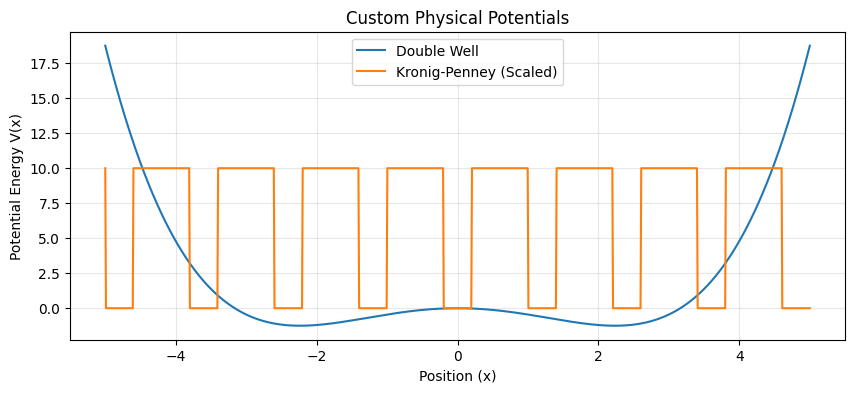

In [2]:
def potential_infinite_well(x):
    return np.zeros_like(x)

def potential_harmonic_oscillator(x, omega=1.0):
    return 0.5 * (omega**2) * (x**2)

def potential_double_well(x, a=0.5, b=0.05):
    # V(x) = -a*x^2 + b*x^4
    return -a * (x**2) + b * (x**4)

def potential_kronig_penney(x, well_depth=50, well_width=0.4, period=1.2):
    # Using modulo to create a periodic array of square wells
    shifted_x = (x + period/2) % period - period/2
    return np.where(np.abs(shifted_x) < well_width/2, 0, well_depth)

# Quick visualization check of our custom potentials
plt.figure(figsize=(10, 4))
plt.plot(X, potential_double_well(X), label="Double Well")
plt.plot(X, potential_kronig_penney(X, well_depth=10), label="Kronig-Penney (Scaled)")
plt.title("Potentials")
plt.xlabel("Position (x)")
plt.ylabel("Potential Energy V(x)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

FDM SOLVER

In [10]:
class FDMSolver:
    def __init__(self, x_grid):
        self.x = x_grid
        self.N = len(x_grid)
        self.dx = x_grid[1] - x_grid[0]
        self._build_kinetic_matrix()

    def _build_kinetic_matrix(self):
        hbar = 1.0
        m = 1.0
        constant = hbar**2 / (2.0 * m * (self.dx**2))

        # Main diagonal and off-diagonals for the second derivative stencil
        main_diag = 2.0 * constant * np.ones(self.N)
        off_diag = -1.0 * constant * np.ones(self.N - 1)

        self.T = np.diag(main_diag) + np.diag(off_diag, k=1) + np.diag(off_diag, k=-1)

    def solve(self, potential_callable):
        # Evaluate potential energy along the spatial grid
        V_diag = potential_callable(self.x)
        V_matrix = np.diag(V_diag)

        # Total Hamiltonian matrix operator
        H = self.T + V_matrix

        # Solve the standard eigenvalue problem for a symmetric matrix
        eigenvalues, eigenvectors = eigh(H)

        # Transpose eigenvectors so that wavefunctions are easily accessed by index: psi = wavefunctions[n]
        wavefunctions = eigenvectors.T

        # Normalize wavefunctions manually using Romberg/Trapezoidal integration rule: \int |\psi|^2 dx = 1
        for i in range(len(wavefunctions)):
            norm = np.sqrt(np.trapz(wavefunctions[i]**2, self.x))
            wavefunctions[i] /= norm

        return eigenvalues, wavefunctions

print("FDM Solver Class compiled successfully via manual matrix discretization.")

FDM Solver Class compiled successfully via manual matrix discretization.


SHOOTING SOLVER WITH RK4

In [8]:
class ShootingSolver:
    def __init__(self, x_grid):
        self.x = x_grid
        self.N = len(x_grid)
        self.dx = x_grid[1] - x_grid[0]

    def _rk4_step(self, psi, phi, x, E, V_func):
        # Schrodinger Eq transformed to a system of first order ODEs:
        # d(psi)/dx = phi
        # d(phi)/dx = 2*m/hbar^2 * (V(x) - E) * psi
        k1_psi = phi
        k1_phi = 2.0 * (V_func(x) - E) * psi

        k2_psi = phi + 0.5 * self.dx * k1_phi
        k2_phi = 2.0 * (V_func(x + 0.5 * self.dx) - E) * (psi + 0.5 * self.dx * k1_psi)

        k3_psi = phi + 0.5 * self.dx * k2_phi
        k3_phi = 2.0 * (V_func(x + 0.5 * self.dx) - E) * (psi + 0.5 * self.dx * k2_psi)

        k4_psi = phi + self.dx * k3_phi
        k4_phi = 2.0 * (V_func(x + self.dx) - E) * (psi + self.dx * k3_psi)

        next_psi = psi + (self.dx / 6.0) * (k1_psi + 2.0 * k2_psi + 2.0 * k3_psi + k4_psi)
        next_phi = phi + (self.dx / 6.0) * (k1_phi + 2.0 * k2_phi + 2.0 * k3_phi + k4_phi)
        return next_psi, next_phi

    def integrate_wavefunction(self, E, V_func):
        # Boundary conditions at infinity/edges
        psi = np.zeros(self.N)
        phi = np.zeros(self.N)

        # Seeding conditions for an even parity state approximation at the boundary edge
        psi[0] = 0.0
        phi[0] = 1e-5

        for i in range(self.N - 1):
            psi[i+1], phi[i+1] = self._rk4_step(psi[i], phi[i], self.x[i], E, V_func)

        return psi

    def find_eigenvalue_bisection(self, E_min, E_max, V_func, tol=1e-6):
        # Custom bisection root finder evaluating boundary behavior at grid termination
        E_left = E_min
        E_right = E_max

        psi_left = self.integrate_wavefunction(E_left, V_func)[-1]
        psi_right = self.integrate_wavefunction(E_right, V_func)[-1]

        if psi_left * psi_right > 0:
            raise ValueError("Bisection bracket does not contain a unique node boundary flip.")

        while (E_right - E_left) > tol:
            E_mid = 0.5 * (E_left + E_right)
            psi_mid = self.integrate_wavefunction(E_mid, V_func)[-1]

            if psi_left * psi_mid < 0:
                E_right = E_mid
                psi_right = psi_mid
            else:
                E_left = E_mid
                psi_left = psi_mid

        final_E = 0.5 * (E_left + E_right)
        final_psi = self.integrate_wavefunction(final_E, V_func)
        # Normalize
        norm = np.sqrt(np.trapz(final_psi**2, self.x))
        return final_E, final_psi / norm

print("Shooting Method Solver with RK4 integration engine compiled.")

Shooting Method Solver with RK4 integration engine compiled.


COMPUTING EIGENVALUE ACCURACY BY COMPARING NUMERICAL RESULTS TO ANALYTICAL SOLN

/tmp/ipykernel_14137/2012454515.py:36: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm = np.sqrt(np.trapz(wavefunctions[i]**2, self.x))
/tmp/ipykernel_14137/1571748510.py:66: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm = np.sqrt(np.trapz(final_psi**2, self.x))


=== VERIFICATION METRICS ===
Ground State Analytical Energy: 0.5
FDM Solved Energy:             0.499997 (Error: 0.0006%)
Shooting Solved Energy:        0.500000 (Error: 0.0001%)


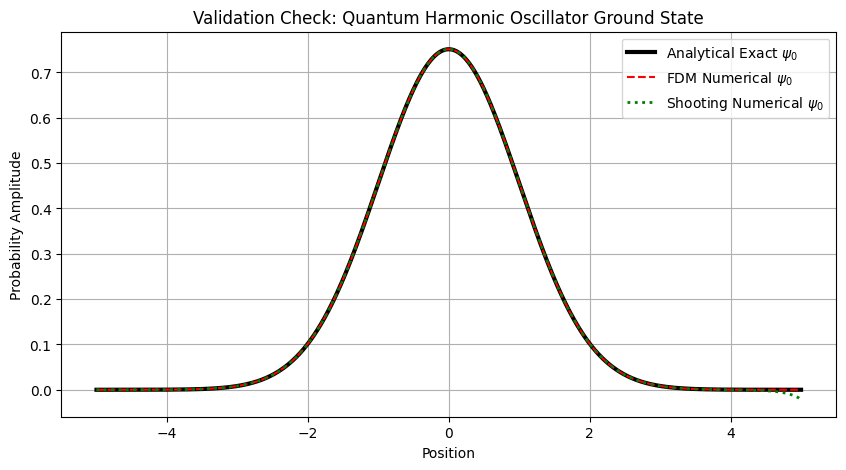

In [5]:
# Instantiate solvers
fdm = FDMSolver(X)
shooter = ShootingSolver(X)

# Compute Numerical results via FDM
fdm_E, fdm_psi = fdm.solve(lambda x: potential_harmonic_oscillator(x, omega=1.0))

# Compute Numerical results via Shooting Method
shoot_E, shoot_psi = shooter.find_eigenvalue_bisection(0.2, 0.8, lambda x: potential_harmonic_oscillator(x, omega=1.0))

# Analytical exact benchmarks
exact_E0 = 0.5
exact_psi0 = (np.pi**(-0.25)) * np.exp(-(X**2) / 2.0)

# Sign reconciliation loop for comparison clarity
if np.sign(fdm_psi[0, 500]) != np.sign(exact_psi0[500]): fdm_psi[0] *= -1
if np.sign(shoot_psi[500]) != np.sign(exact_psi0[500]): shoot_psi *= -1

# Verification metrics output calculations
fdm_error = abs(fdm_E[0] - exact_E0) / exact_E0 * 100
shoot_error = abs(shoot_E - exact_E0) / exact_E0 * 100

print("=== VERIFICATION METRICS ===")
print(f"Ground State Analytical Energy: {exact_E0}")
print(f"FDM Solved Energy:             {fdm_E[0]:.6f} (Error: {fdm_error:.4f}%)")
print(f"Shooting Solved Energy:        {shoot_E:.6f} (Error: {shoot_error:.4f}%)")

# Validation Plotting
plt.figure(figsize=(10, 5))
plt.plot(X, exact_psi0, 'k-', lw=3, label=r'Analytical Exact $\psi_0$')
plt.plot(X, fdm_psi[0], 'r--', lw=1.5, label=r'FDM Numerical $\psi_0$')
plt.plot(X, shoot_psi, 'g:', lw=2, label=r'Shooting Numerical $\psi_0$')
plt.title("Validation Check: Quantum Harmonic Oscillator Ground State")
plt.xlabel("Position")
plt.ylabel("Probability Amplitude")
plt.legend()
plt.grid(True)
plt.show()

Periodic lattice solutions and double well potential

/tmp/ipykernel_14137/2012454515.py:36: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm = np.sqrt(np.trapz(wavefunctions[i]**2, self.x))


=== DOUBLE WELL STATE ENERGY TUNNELING SPLITTING ===
Ground State E0: -0.91337
First Excited E1: -0.89235
Energy Gap (ΔE Splitting): 0.02102

=== KRONIG PENNY BAND===
State Eigenvalue E_0: 14.0892
State Eigenvalue E_1: 14.1320
State Eigenvalue E_2: 14.1997
State Eigenvalue E_3: 14.2867
State Eigenvalue E_4: 14.3857
State Eigenvalue E_5: 14.4874
State Eigenvalue E_6: 14.5817


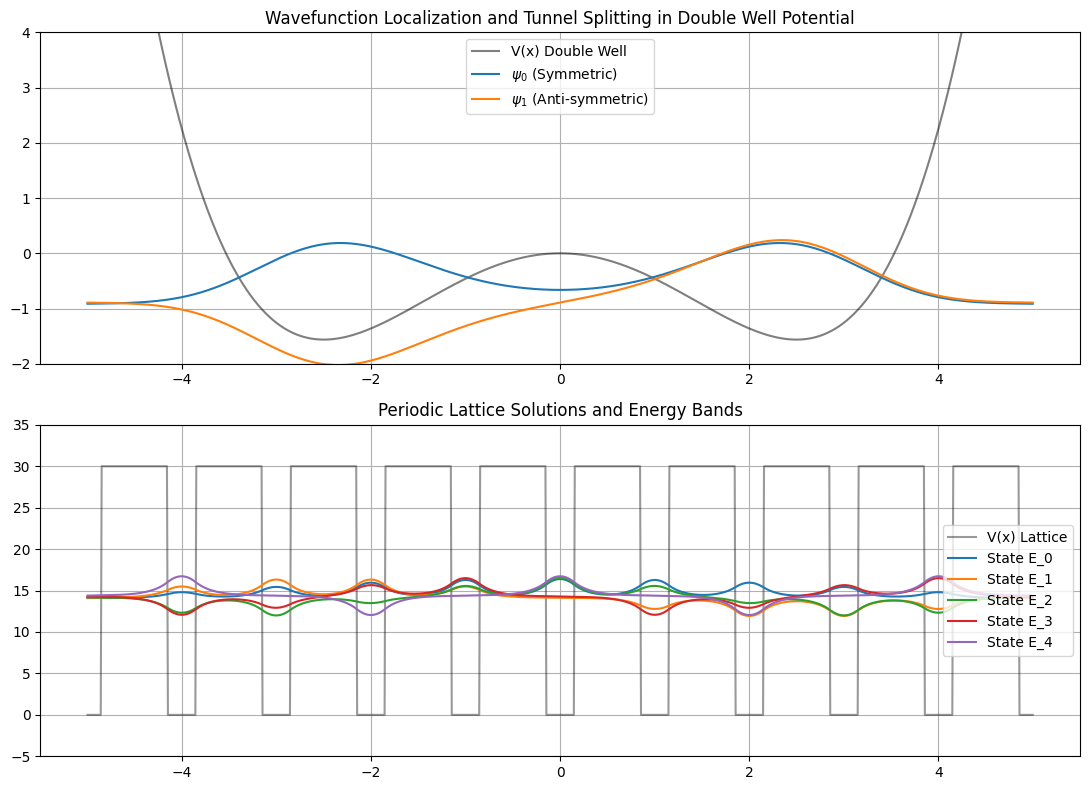

In [12]:
# Part A: Double Well Potential Splitting Analysis
E_double, psi_double = fdm.solve(lambda x: potential_double_well(x, a=0.5, b=0.04))

print("=== DOUBLE WELL STATE ENERGY TUNNELING SPLITTING ===")
print(f"Ground State E0: {E_double[0]:.5f}")
print(f"First Excited E1: {E_double[1]:.5f}")
print(f"Energy Gap (\u0394E Splitting): {E_double[1] - E_double[0]:.5f}\n")

#PartB:PeriodicLatticeBandGapAnalysis
E_kp, psi_kp = fdm.solve(lambda x: potential_kronig_penney(x, well_depth=30, well_width=0.3, period=1.0))

print("=== KRONIG PENNY BAND===")
for i in range(7):
    print(f"State Eigenvalue E_{i}: {E_kp[i]:.4f}")

# Visualization layout
fig, ax = plt.subplots(2, 1, figsize=(11, 8))

# Double well plot
ax[0].plot(X, potential_double_well(X, a=0.5, b=0.04), 'k-', alpha=0.5, label='V(x) Double Well')
ax[0].plot(X, psi_double[0]*2 + E_double[0], label=r'$\psi_0$ (Symmetric)')
ax[0].plot(X, psi_double[1]*2 + E_double[1], label=r'$\psi_1$ (Anti-symmetric)')
ax[0].set_title("Wavefunction Localization and Tunnel Splitting in Double Well Potential")
ax[0].set_ylim(-2, 4)
ax[0].legend()
ax[0].grid(True)

# Kronig Penney plot
ax[1].plot(X, potential_kronig_penney(X, well_depth=30, well_width=0.3, period=1.0), 'k-', alpha=0.4, label='V(x) Lattice')
for n in range(5):
    ax[1].plot(X, psi_kp[n]*3 + E_kp[n], label=f'State E_{n}')
ax[1].set_title("Periodic Lattice Solutions and Energy Bands")
ax[1].set_ylim(-5, 35)
ax[1].legend(loc='right')
ax[1].grid(True)

plt.tight_layout()
plt.show()

Parameter change slider

In [13]:
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider
%matplotlib inline

# Pre-calculate baseline potential and initial solutions
init_omega = 1.0

def interactive_quantum_playground(omega):
    current_potential = potential_harmonic_oscillator(X, omega=omega)

    # Solve the system using our FDM solver instance
    E_new, psi_new = fdm.solve(lambda x: potential_harmonic_oscillator(x, omega=omega))

    # Plot configuration
    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot potential energy curve
    ax.plot(X, current_potential, 'k-', alpha=0.4, label=r'Potential $V(x)$')

    # Plot scaled wavefunctions shifted by their corresponding eigenvalues
    ax.plot(X, psi_new[0]*3 + E_new[0], 'r-', label=r'Ground State $\psi_0$')
    ax.plot(X, psi_new[1]*3 + E_new[1], 'g-', label=r'Excited State $\psi_1$')

    # Formatting adjustments — Added 'fr' to make it a raw f-string
    ax.set_ylim(-0.5, 6)
    ax.set_xlim(X_MIN, X_MAX)
    ax.set_title(fr"Live Solver Interaction: Quantum Harmonic Oscillator ($\omega$ = {omega:.2f})")
    ax.set_xlabel("Spatial Coordinates (x)")
    ax.set_ylabel("Energy Scale / Wavefunction Magnitude")
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

    plt.show()

# Render a robust HTML5 interactive slider directly in the notebook output
interact(
    interactive_quantum_playground,
    omega=FloatSlider(min=0.2, max=3.0, step=0.05, value=init_omega, description=r'Frequency ($\omega$)')
);

interactive(children=(FloatSlider(value=1.0, description='Frequency ($\\omega$)', max=3.0, min=0.2, step=0.05)…